In [1]:
import numpy as np
import pandas as pd
from numpy import hstack
from numpy import concatenate
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import GaussianNoise
from keras.layers import Masking
from keras import optimizers
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings('ignore')

# {'DD': 0.001, 'DP2': 0.0004, 'DP1': 0.00035, 'HP1': 0.00005, 'HP2': 0.0001, 'HD': 0.0002}

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


2023-12-14 18:32:00.518465: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv('daily_total.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df[df['DATE'] > '2022-08-10']
# fill missing dates with 0
df.index = df['DATE']
df = df.reindex(pd.date_range(min(df['DATE']), max(df['DATE'])), fill_value=0).drop('DATE', axis=1)
df['DATE'] = df.index
# df.drop(['DATE'], axis=1, inplace=True)
df

,USERCOUNT,SECONDSSPENT,QUANTITY,VOLUME,WEIGHT,PRICE,DATE
2022-08-16,15,24864,1564,5.510447,606.628000,7714.46,2022-08-16
2022-08-17,46,648639,153271,900.823306,87245.837728,731227.04,2022-08-17
2022-08-18,72,1535976,353781,2687.981897,247269.820740,2135600.74,2022-08-18
2022-08-19,70,1253113,395921,2944.799061,262781.058485,2136707.30,2022-08-19
2022-08-20,6,67002,593,14.290446,975.280591,14861.86,2022-08-20
...,...,...,...,...,...,...,...
2023-09-25,101,1171721,854092,2678.434373,292547.191456,1875797.61,2023-09-25
2023-09-26,110,1249771,1016887,3483.392239,371822.547589,2318629.60,2023-09-26
2023-09-27,104,1257222,939123,2998.222002,300263.198492,1850064.42,2023-09-27
2023-09-28,109,1339688,1224169,3863.465093,384720.606181,2390796.27,2023-09-28


In [8]:
df_wo = pd.read_csv('daily_wo_total.csv')
df_wo['DATE'] = pd.to_datetime(df_wo['DATE'])
df_wo = df_wo[df_wo['DATE'] > '2022-08-03']
# fill missing dates with 0
df_wo.index = df_wo['DATE']
df_wo = df_wo.reindex(pd.date_range(min(df_wo['DATE']), max(df_wo['DATE'])), fill_value=0).drop('DATE', axis=1)
df_wo['DATE'] = df_wo.index
# df_wo.drop(['DATE'], axis=1, inplace=True)
df_wo[['WOANBL']] = df_wo[['WOANBL']].shift(7)
df_wo

,WOANBL,DATE
2022-08-04,NaN,2022-08-04
2022-08-05,NaN,2022-08-05
2022-08-06,NaN,2022-08-06
2022-08-07,NaN,2022-08-07
2022-08-08,NaN,2022-08-08
...,...,...
2023-10-09,0.0,2023-10-09
2023-10-10,0.0,2023-10-10
2023-10-11,0.0,2023-10-11
2023-10-12,0.0,2023-10-12


In [9]:
df_combined = pd.merge(df, df_wo, on='DATE', how='left')
df_combined = df_combined[df_combined['DATE'] < '2023-10-14']
print(df_combined.corr())
df_combined = df_combined[['DATE', 'WOANBL', 'SECONDSSPENT']]
df_combined.columns = ['DATE', 'WOANBL', 'SECONDSSPENT']
df_combined

              USERCOUNT  SECONDSSPENT  QUANTITY    VOLUME    WEIGHT     PRICE  \
USERCOUNT      1.000000      0.942946  0.845696  0.887294  0.899947  0.665914   
SECONDSSPENT   0.942946      1.000000  0.884744  0.911248  0.934875  0.686964   
QUANTITY       0.845696      0.884744  1.000000  0.860263  0.928506  0.601137   
VOLUME         0.887294      0.911248  0.860263  1.000000  0.976150  0.727141   
WEIGHT         0.899947      0.934875  0.928506  0.976150  1.000000  0.707397   
PRICE          0.665914      0.686964  0.601137  0.727141  0.707397  1.000000   
DATE          -0.143678     -0.319066 -0.403173 -0.231109 -0.289923 -0.154856   
WOANBL         0.456938      0.484330  0.341455  0.356473  0.368850  0.291693   

                  DATE    WOANBL  
USERCOUNT    -0.143678  0.456938  
SECONDSSPENT -0.319066  0.484330  
QUANTITY     -0.403173  0.341455  
VOLUME       -0.231109  0.356473  
WEIGHT       -0.289923  0.368850  
PRICE        -0.154856  0.291693  
DATE          1.000000 -0

,DATE,WOANBL,SECONDSSPENT
0,2022-08-16,17846.0,24864
1,2022-08-17,8907.0,648639
2,2022-08-18,7781.0,1535976
3,2022-08-19,11039.0,1253113
4,2022-08-20,3890.0,67002
...,...,...,...
405,2023-09-25,634.0,1171721
406,2023-09-26,0.0,1249771
407,2023-09-27,0.0,1257222
408,2023-09-28,0.0,1339688


In [10]:
# correlation matrix of all features
print(df_combined.corr())

                  DATE     ORDER  SECONDSSPENT
DATE          1.000000 -0.261365     -0.316735
ORDER        -0.261365  1.000000      0.678063
SECONDSSPENT -0.316735  0.678063      1.000000


In [19]:
seconds_spent = df_combined['SECONDSSPENT'].values.reshape(-1, 1)
order = df_combined['ORDER'].values.reshape(-1, 1)
price = df_combined['PRICE'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))

dataset = scaler.fit_transform(hstack((order, price, seconds_spent)))

In [20]:
# def df_to_X_y(dataset, window_size=1):
#     # dataset = df.values
#     X = []
#     y = []
#     for i in range(len(dataset) - window_size):
#         row = [[j] for j in dataset[i: i + window_size, :]]
#         # row = dataset[i: i + window_size]
#         X.append(row)
#         y.append(dataset[i + window_size][-1])
#     return np.array(X), np.array(y)

# split = int(len(dataset) * 0.9)
# window_size = 1

# X, y = df_to_X_y(dataset, window_size)
# print(X.shape, y.shape)
# train_X, train_y = X[:split], y[:split]
# test_X, test_y = X[split:], y[split:]

# train_X = train_X.reshape((train_X.shape[0], train_X.shape[1], train_X.shape[3]))
# test_X = test_X.reshape((test_X.shape[0], test_X.shape[1], test_X.shape[3]))

# # train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
# # test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))

# print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

In [21]:
# split into train and test sets
split = int(len(dataset) * 0.8)

train, test = dataset[:split], dataset[split:]

train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]

train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(310, 1, 2) (310,) (78, 1, 2) (78,)


Epoch 1/150


2023-12-14 15:34:40.905117: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [310]
	 [[{{node Placeholder/_11}}]]
2023-12-14 15:34:40.905396: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [310]
	 [[{{node Placeholder/_11}}]]
2023-12-14 15:34:45.532400: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [78]


10/10 - 6s - loss: 0.3695 - val_loss: 0.2000 - 6s/epoch - 612ms/step
Epoch 2/150
10/10 - 0s - loss: 0.3688 - val_loss: 0.1995 - 49ms/epoch - 5ms/step
Epoch 3/150
10/10 - 0s - loss: 0.3684 - val_loss: 0.1991 - 44ms/epoch - 4ms/step
Epoch 4/150
10/10 - 0s - loss: 0.3679 - val_loss: 0.1988 - 44ms/epoch - 4ms/step
Epoch 5/150
10/10 - 0s - loss: 0.3675 - val_loss: 0.1984 - 44ms/epoch - 4ms/step
Epoch 6/150
10/10 - 0s - loss: 0.3670 - val_loss: 0.1980 - 45ms/epoch - 4ms/step
Epoch 7/150
10/10 - 0s - loss: 0.3666 - val_loss: 0.1977 - 43ms/epoch - 4ms/step
Epoch 8/150
10/10 - 0s - loss: 0.3661 - val_loss: 0.1973 - 45ms/epoch - 5ms/step
Epoch 9/150
10/10 - 0s - loss: 0.3657 - val_loss: 0.1969 - 44ms/epoch - 4ms/step
Epoch 10/150
10/10 - 0s - loss: 0.3652 - val_loss: 0.1966 - 42ms/epoch - 4ms/step
Epoch 11/150
10/10 - 0s - loss: 0.3647 - val_loss: 0.1962 - 41ms/epoch - 4ms/step
Epoch 12/150
10/10 - 0s - loss: 0.3643 - val_loss: 0.1958 - 41ms/epoch - 4ms/step
Epoch 13/150
10/10 - 0s - loss: 0.363

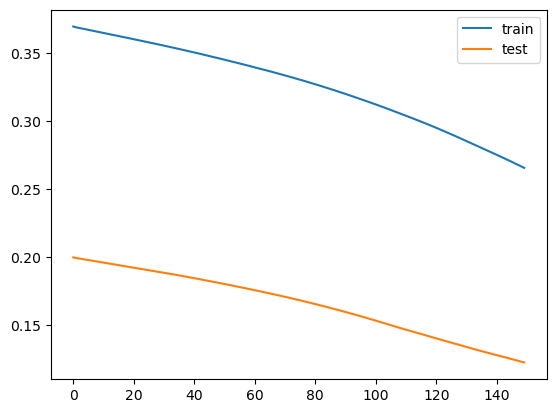

In [22]:
# design network
np.random.seed(1234)
tf.random.set_seed(1234)

tf.keras.utils.set_random_seed(1234)
tf.config.experimental.enable_op_determinism()

optim = optimizers.Adam(lr=0.00005)
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(LSTM(16, input_shape=(train_X.shape[1], train_X.shape[2]), return_sequences=True))
model.add(LSTM(8, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dense(1))
model.compile(loss='mae', optimizer=optim)

# fit network
history = model.fit(train_X, train_y, epochs=150, batch_size=32, validation_data=(test_X, test_y), verbose=2, shuffle=False)

# plot history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [23]:
# make a prediction
yhat = model.predict(test_X)
X = test_X.reshape((test_X.shape[0], test_X.shape[2]))
print(X.shape, yhat.shape)

# invert scaling for forecast
inv_yhat = concatenate((X, yhat), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:, -1]

# invert scaling for actual
y = test_y.reshape((len(test_y), 1))
dataset_y = concatenate((X, y), axis=1)
dataset_y = scaler.inverse_transform(dataset_y)
inv_y = dataset_y[:, -1]
# inv_y = scaler.inverse_transform(test_y)
# inv_y = inv_y[:, -1]

2023-12-14 15:34:53.691044: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [78,1,2]
	 [[{{node Placeholder/_10}}]]
2023-12-14 15:34:53.691272: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [78,1,2]
	 [[{{node Placeholder/_10}}]]


3/3 [==============================] - 2s 2ms/step
(78, 2) (78, 1)


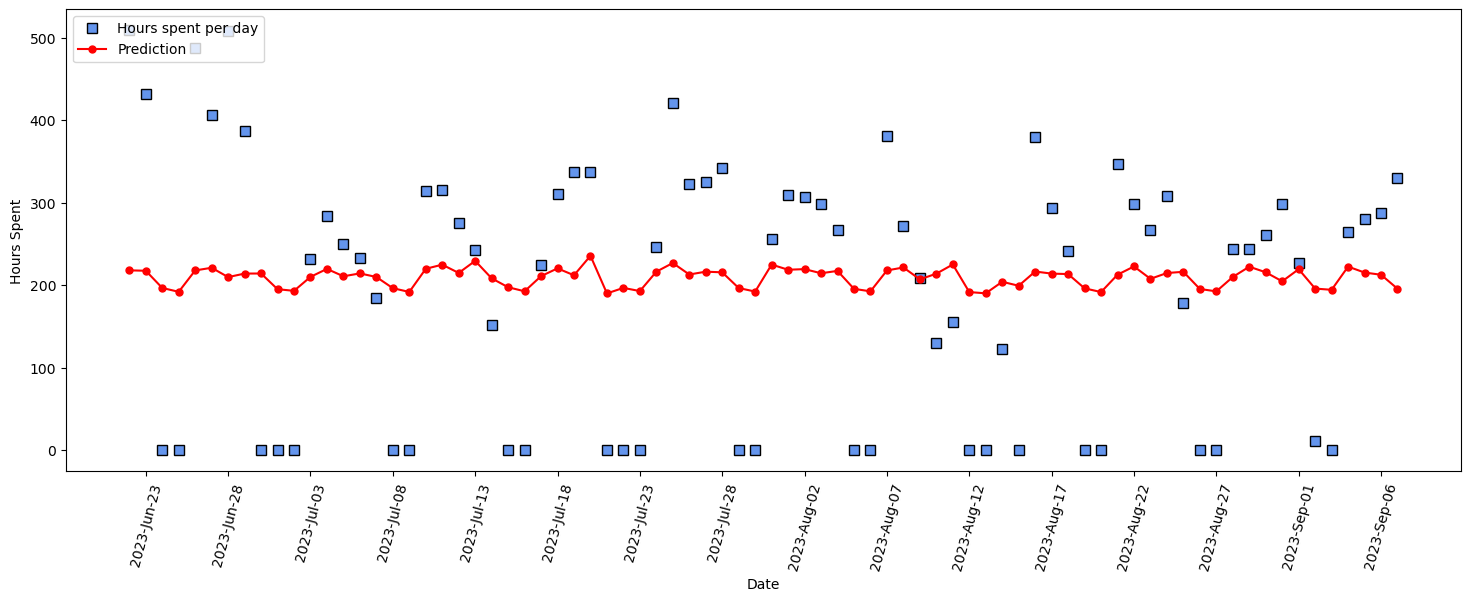

In [24]:
date = df_combined['DATE'][split:]

fig, ax = plt.subplots()
fig.set_size_inches(18, 6)
ax.plot(date, inv_y / 3600, 
        linestyle='none', 
        marker='s',
        markerfacecolor='cornflowerblue', 
        markeredgecolor='black',
        markersize=7,
        label='Hours spent per day')
ax.plot(date, inv_yhat / 3600, 
        linestyle='-',
        marker='o',
        markersize=5,
        color='red',
        label='Prediction')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
ax.set_xlabel('Date')
ax.set_ylabel('Hours Spent')
plt.xticks(rotation=75)
ax.legend(loc='upper left')
plt.show()


In [25]:
# MAE
mae = mean_absolute_error(inv_y, inv_yhat) / 3600
print('MAE: %.3f' % (mae))

MAE: 123.788


In [26]:
# wo wl hr
# task type: mar